In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    roc_auc_score
)
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.model_selection import GridSearchCV
import joblib

In [2]:
x_train_pre = joblib.load('x_train_presplit_smote.pkl')
y_train_pre = joblib.load('y_train_presplit_smote.pkl')
x_test_pre  = joblib.load('x_test_presplit_smote.pkl')
y_test_pre  = joblib.load('y_test_presplit_smote.pkl')


In [3]:
rf_model_pre = RandomForestClassifier(
    n_estimators=100,
    random_state=20
)
rf_model_pre.fit(x_train_pre, y_train_pre)

RandomForestClassifier(random_state=20)

In [4]:
rf_pred_pre = rf_model_pre.predict(x_test_pre)
rf_prob_pre = rf_model_pre.predict_proba(x_test_pre)[:, 1]
print(rf_prob_pre)


[0.89 0.5  0.56 0.38 0.9  0.38 0.55 0.96 0.77 0.55 0.44 0.7  0.74 0.76
 0.4  0.87 0.97 0.75 0.74 0.75 0.22 0.09 0.09 0.15 0.19 0.4  0.66 0.89
 0.93 0.8  0.2  0.2  0.13 0.28 0.92 0.93 0.37 0.3  0.25 0.45 0.2  0.32
 0.29 0.85 0.5  0.77 0.69 0.3  0.48 0.36 0.29 0.77 0.86 0.86 0.77 0.31
 0.39 0.76 0.41 0.37 0.22 0.89 0.41 0.38 0.38 0.74 0.66 0.29 0.31 0.7
 0.15 0.94 0.37 0.59 0.94 0.87 0.94 0.28 0.65 0.86 0.73 0.16 0.24 0.47
 0.15 0.81 0.63 0.61 0.97 0.93 0.79 0.63 0.2  0.71 0.38 0.59 0.67 0.97
 0.23 0.28 0.45 0.78 0.8  0.94 0.19 0.25 0.73 0.22 0.23 0.65 0.53 0.07
 0.53 0.9  0.42 0.92 0.08 0.33 0.19 0.26 0.94 0.9  0.48 0.65 0.2  0.46
 0.17 0.25 0.62 0.24 0.65 0.66 0.72 0.86 0.96 0.62 0.49 0.89 0.89 0.33
 0.17 0.53 0.27 0.84 0.69 0.55 0.35 0.69 0.16 0.4  0.15 0.64 0.89 0.22
 0.11 0.82 0.15 0.66 0.61 0.22 0.39 0.63 0.55 0.75 0.82 0.28 0.68 0.8
 0.82 0.46 0.59 0.62 0.84 0.88 0.67 0.27 0.14 0.6  0.66 0.15 0.26 0.45
 0.8  0.28 0.8  0.63 0.09 0.58 0.81 0.9  0.92 0.53 0.93 0.79 0.34 0.39
 0.05 0.

In [5]:
rf_accuracy_pre = accuracy_score(y_test_pre, rf_pred_pre)
print("Random Forest Accuracy (Pre-split SMOTE):", round(rf_accuracy_pre, 4))


Random Forest Accuracy (Pre-split SMOTE): 0.9043


In [6]:
print("Classification Report\n")
print(classification_report(y_test_pre, rf_pred_pre))

Classification Report

              precision    recall  f1-score   support

           0       0.90      0.91      0.90       339
           1       0.91      0.90      0.90       340

    accuracy                           0.90       679
   macro avg       0.90      0.90      0.90       679
weighted avg       0.90      0.90      0.90       679



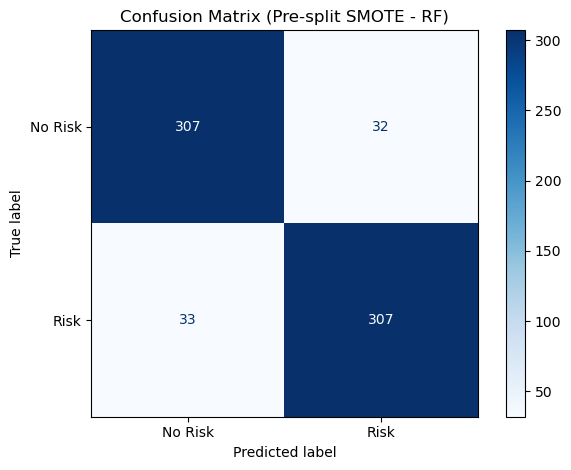

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test_pre, rf_pred_pre, display_labels=['No Risk', 'Risk'], cmap='Blues'
)
plt.title("Confusion Matrix (Pre-split SMOTE - RF)")
plt.tight_layout()
plt.show()

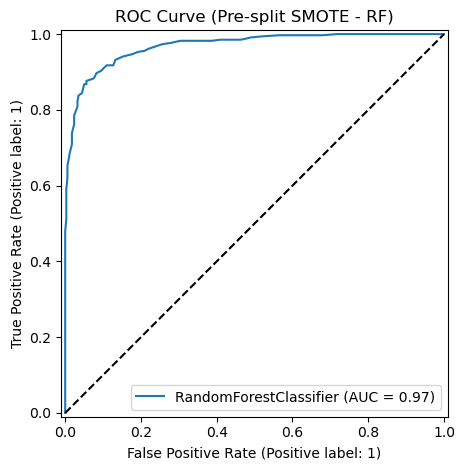

ROC-AUC Score: 0.9687


In [8]:
RocCurveDisplay.from_estimator(rf_model_pre, x_test_pre, y_test_pre)
plt.title('ROC Curve (Pre-split SMOTE - RF)')
plt.plot([0, 1], [0, 1], 'k--')
plt.tight_layout()
plt.show()

print('ROC-AUC Score:', roc_auc_score(y_test_pre, rf_prob_pre).round(4))

In [9]:
feature_names_pre = joblib.load('feature_names_presplit_smote.pkl')  # saved earlier
n_importances = len(rf_model_pre.feature_importances_)

if len(feature_names_pre) == n_importances:
    labels = feature_names_pre
else:
    labels = [f"feature_{i}" for i in range(n_importances)]

feature_importance_pre = pd.DataFrame({
    "Feature": labels,
    "Importance": rf_model_pre.feature_importances_,
})

In [10]:
feature_importance_pre = feature_importance_pre.sort_values(by="Importance", ascending=False)


In [11]:
print("\nFeature Importances (Pre-split SMOTE):")
print(feature_importance_pre.to_string(index=False))


Feature Importances (Pre-split SMOTE):
 Feature  Importance
       9    0.105676
      12    0.087205
      13    0.067756
      18    0.062229
      14    0.059467
      10    0.059435
       8    0.057731
       6    0.055898
       7    0.055044
      11    0.054999
      15    0.053309
      16    0.046612
       0    0.042366
      24    0.025408
       1    0.020888
      25    0.020116
      19    0.017510
      21    0.016680
      17    0.016355
       2    0.012753
       4    0.012039
      23    0.011868
       3    0.009087
      20    0.007799
      22    0.007727
      26    0.006873
      27    0.006350
       5    0.000820


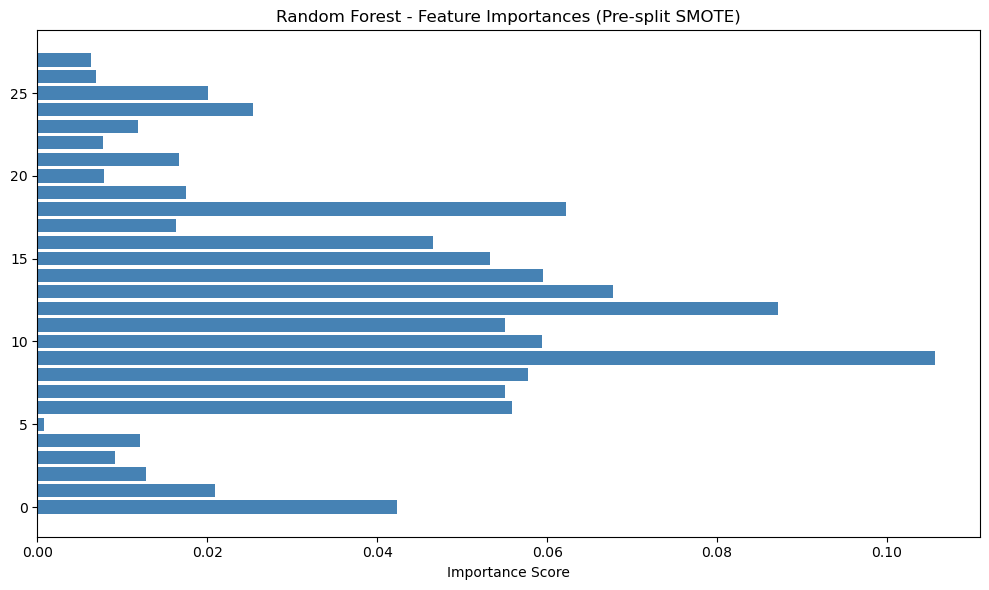

In [12]:
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_pre["Feature"], feature_importance_pre["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("Random Forest - Feature Importances (Pre-split SMOTE)")
plt.tight_layout()
plt.show()


In [14]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
}

grid_search_pre = GridSearchCV(
    RandomForestClassifier(random_state=20),
    param_grid, cv=5, scoring='roc_auc', n_jobs=-1
)
grid_search_pre.fit(x_train_pre, y_train_pre)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=20), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='roc_auc')

In [15]:
print("Best Params:", grid_search_pre.best_params_)
best_model_pre = grid_search_pre.best_estimator_

Best Params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}


In [16]:
cv_scores_pre = cross_val_score(rf_model_pre, x_train_pre, y_train_pre, cv=5, scoring='roc_auc')
print("CV ROC-AUC Scores:", cv_scores_pre.round(4))
print("Mean:", cv_scores_pre.mean().round(4), "| Std dev:", cv_scores_pre.std().round(4))


CV ROC-AUC Scores: [0.9603 0.9577 0.9562 0.9636 0.9597]
Mean: 0.9595 | Std dev: 0.0025


In [17]:
joblib.dump(rf_model_pre, 'random_forest_model_presplit_smote.pkl')
print("Model saved.")

print("Classification Report (Final)\n")
print(classification_report(y_test_pre, rf_pred_pre))

Model saved.
Classification Report (Final)

              precision    recall  f1-score   support

           0       0.90      0.91      0.90       339
           1       0.91      0.90      0.90       340

    accuracy                           0.90       679
   macro avg       0.90      0.90      0.90       679
weighted avg       0.90      0.90      0.90       679

